# Loading a pretrained model from the Hugging Face Hub

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/urancon/deepSTRF/blob/develop/examples/load_pretrained_statenet_ns1.ipynb)

deepSTRF ships a curated set of pretrained checkpoints on the
[Hugging Face Hub](https://huggingface.co/urancon). Loading one is a
single line:

```python
model = StateNet.from_pretrained("urancon/deepSTRF-statenet-gru-ns1")
```

This notebook walks through what that does under the hood, how to
reproduce the published test metrics, and how to inspect the metadata
we shipped alongside the weights. The full registry of pretrained models
(and the recipes used to train them) lives in the docs:
[`pretrained_models.md`](../docs/_source/md/pretrained_models.md).

## Setup — Google Colab

On Colab, install deepSTRF from source. On a local install (`pip install -e .`)
this is a no-op.

In [1]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/urancon/deepSTRF.git
    print("deepSTRF installed from GitHub.")
else:
    print("Local environment — assuming deepSTRF is already importable.")

Local environment — assuming deepSTRF is already importable.


## Imports

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset

from deepSTRF.datasets.audio.NS1_DRC_Dataset import NS1_Dataset
from deepSTRF.metrics import corrcoef, normalized_corrcoef
from deepSTRF.models.audio import StateNet
from deepSTRF.utils.data import neural_collate

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 1. Load the checkpoint

`from_pretrained` does three things behind the scenes:

1. **Resolves the repo** — if the argument is an existing local folder,
   it's used directly; otherwise it's treated as a Hub `repo_id` and
   downloaded into `~/.cache/huggingface/hub` (idempotent + resumable).
2. **Reads `config.json`** — the architecture kwargs that were
   auto-captured when the model was constructed at training time, plus
   a `_model_class` sentinel for safety.
3. **Calls `StateNet(**config)`** then `load_state_dict` from
   `model.safetensors`.

The optional `return_metadata=True` also fetches the `metadata.json` blob
we publish next to the weights (test metrics, training config, deepSTRF
commit SHA used at training time).

In [3]:
REPO_ID = "urancon/deepSTRF-statenet-gru-ns1"

model, metadata = StateNet.from_pretrained(
    REPO_ID, map_location=device, return_metadata=True,
)
model.eval()

print(f"class:           {type(model).__name__}")
print(f"out_neurons:     {model.O}")
print(f"trainable params:{model.count_trainable_params():>9,}")

/home/ulysse/miniconda3/envs/deepstrf_dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 15065.75it/s]

class:           StateNet
out_neurons:     119
trainable params:   39,081


## 2. Inspect the published metadata

Everything we know about the checkpoint at upload time is recorded in
`metadata`. The same blob is the source of truth for the registry entry
in [`pretrained_models.md`](../docs/_source/md/pretrained_models.md).

In [4]:
import json
print(json.dumps(metadata, indent=2, sort_keys=True))

{
  "dataset": "NS1 (Harper et al. 2016, Rahman et al. 2020)",
  "library": "deepSTRF",
  "library_commit": "c07e561f7835454fdacbb35f38a8957668b8d1fd",
  "model_kwargs": {
    "connectivity": "LC",
    "hidden_channels": 7,
    "kernel_size": 7,
    "n_frequency_bands": 34,
    "rnn_type": "GRU",
    "stride": 3
  },
  "out_neurons": 119,
  "split": {
    "test_stim_idx": [
      17,
      18,
      19
    ],
    "train_stim_idx": [
      0,
      1,
      2,
      3,
      4,
      5,
      6,
      7,
      8,
      9,
      10,
      11,
      12,
      13
    ],
    "val_stim_idx": [
      14,
      15,
      16
    ]
  },
  "task": "audio neural response prediction",
  "test_metrics": {
    "cc_mean": 0.659480631351471,
    "cc_median": 0.681122899055481,
    "cc_norm_mean": 0.7703116536140442,
    "cc_norm_median": 0.7958264350891113,
    "loss": 0.015971951186656952
  },
  "training": {
    "device": "cuda",
    "epochs_run": 80,
    "fitter_kwargs": {
      "max_epochs": 80,
  

## 3. Reproduce the test split

We auto-download NS1 and rebuild the same train/val/test stim split that
was used at training time. The split indices are stored in
`metadata['split']`, so any future change to the recipe is automatically
reflected here.

In [5]:
ds = NS1_Dataset(dt_ms=5.0, smooth=True, download=True)
test_idx = metadata['split']['test_stim_idx']
test_loader = DataLoader(Subset(ds, test_idx), batch_size=1,
                         shuffle=False, collate_fn=neural_collate)
print(f"NS1: {ds.N_neurons} cells, {len(ds.stims)} stims")
print(f"test stims: {test_idx}")

NS1: 119 cells, 20 stims
test stims: [17, 18, 19]


## 4. Run inference and compute test metrics

We run the canonical metrics from `metrics_paradigm.md` §6: per-cell
Pearson `cc` against the trial-averaged PSTH, and Schoppe-style
noise-corrected `cc_norm` against the full multi-trial response array.
Both are NaN-aware so cells / timepoints with missing data don't bias
the average.

We then assert that the recomputed numbers match the ones we shipped
in `metadata` — if they ever drift, something has changed in the dataset
loader or the metrics that wasn't accounted for at training time.

In [6]:
model.to(device)
preds, resps = [], []
with torch.no_grad():
    for stim, resp, mask, _ in test_loader:
        stim = stim.to(device)
        pred = model(stim)                          # (1, N, 1, T)
        preds.append(pred.cpu()); resps.append(resp.cpu())

# Concatenate along the BATCH axis — the canonical pattern from
# metrics_paradigm.md §7 / §11. normalized_corrcoef length-weights the
# signal-power estimate per stim, so each held-out stim must remain a
# distinct entry along dim 0 rather than getting time-glued into one
# long sequence.
pred_cat = torch.cat(preds, dim=0)        # (B=3, N, 1, T)
resp_cat = torch.cat(resps, dim=0)        # (B=3, N, R=20, T)

test_cc      = corrcoef(pred_cat, resp_cat, reduction='none')
test_cc_norm = normalized_corrcoef(pred_cat, resp_cat, method='schoppe', reduction='none')

summary = {
    'cc_mean':         float(torch.nanmean(test_cc)),
    'cc_median':       float(torch.nanmedian(test_cc)),
    'cc_norm_mean':    float(torch.nanmean(test_cc_norm)),
    'cc_norm_median':  float(torch.nanmedian(test_cc_norm)),
}
for k, v in summary.items():
    print(f"{k:>16s}: {v:+.4f}")

         cc_mean: +0.6595
       cc_median: +0.6811
    cc_norm_mean: +0.7703
  cc_norm_median: +0.7958


In [7]:
# Assert reproducibility against the published numbers.
expected = metadata['test_metrics']
for k, observed in summary.items():
    target = expected[k]
    diff = abs(observed - target)
    assert diff < 1e-3, (
        f"{k}: observed {observed:+.6f} vs published {target:+.6f} "
        f"(diff {diff:.2e}). Did the dataset loader change?"
    )
    print(f"{k:>16s}: observed {observed:+.4f}  vs  published {target:+.4f}  ✅")

         cc_mean: observed +0.6595  vs  published +0.6595  ✅
       cc_median: observed +0.6811  vs  published +0.6811  ✅
    cc_norm_mean: observed +0.7703  vs  published +0.7703  ✅
  cc_norm_median: observed +0.7958  vs  published +0.7958  ✅


## 5. Visualise predictions

Pick the best, median, and worst cells (by test `cc_norm`) and overlay
the model's prediction on the trial-averaged response for one held-out
stimulus.

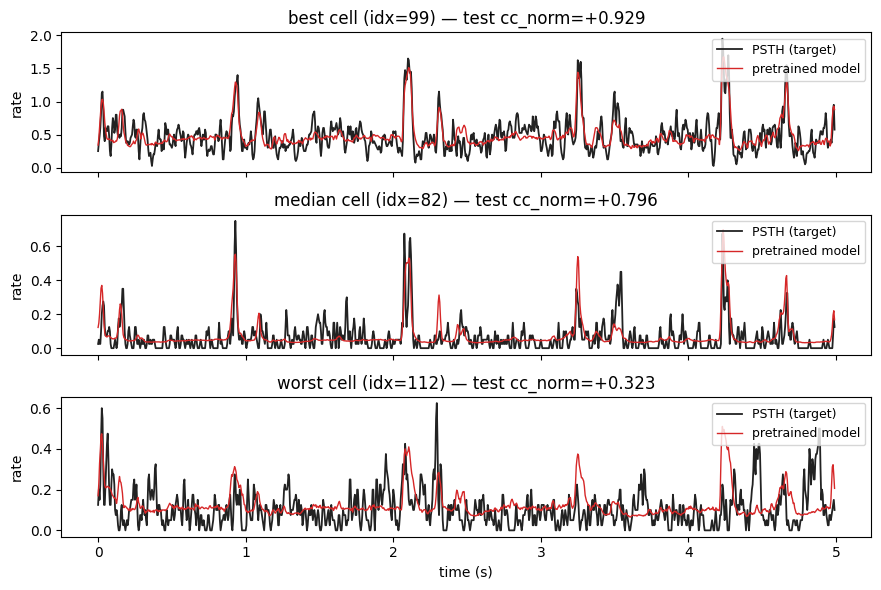

In [8]:
ranking = test_cc_norm.argsort(descending=True)
best, median, worst = ranking[0].item(), ranking[len(ranking) // 2].item(), ranking[-1].item()
picks = [("best", best), ("median", median), ("worst", worst)]

# Run inference on the first held-out stim.
with torch.no_grad():
    stim0 = ds.stims[test_idx[0]].unsqueeze(0).to(device)
    pred0 = model(stim0).cpu().squeeze(0).squeeze(1)         # (N, T)
psth0 = torch.stack([r.mean(dim=0) for r in ds.responses[test_idx[0]]])

t = np.arange(pred0.shape[1]) * 5e-3
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, (label, idx) in zip(axs, picks):
    ax.plot(t, psth0[idx].numpy(), label="PSTH (target)", lw=1.3, color="#222")
    ax.plot(t, pred0[idx].numpy(), label="pretrained model", lw=1.0, color="#d62728")
    ax.set_ylabel("rate")
    ax.set_title(f"{label} cell (idx={idx}) — test cc_norm={test_cc_norm[idx]:+.3f}")
    ax.legend(loc="upper right", fontsize=9)
axs[-1].set_xlabel("time (s)")
plt.tight_layout(); plt.show()

## What's next

- **Browse the registry** —
  [`pretrained_models.md`](../docs/_source/md/pretrained_models.md) lists
  every checkpoint we publish, the architectures, training recipes, and
  test metrics. Each entry is reproducible from the recipe + the deepSTRF
  commit SHA recorded in its `metadata.json` on the Hub.
- **Publish your own** — after training, `model.push_to_hub("your-name/your-model")`
  is the upload counterpart to `from_pretrained`. You'll need to be
  authenticated with `hf auth login` and have write access to the repo.
- **Custom prefiltering** — if your model used a non-JSON `__init__`
  argument (e.g. an `AdapTrans` prefilter instance), pass it back via
  `from_pretrained(..., extra_kwargs={'prefiltering': ...})`. The saved
  `config.json` only stores JSON-serialisable kwargs.